# Taller — Construye y ajusta tu propio clasificador de imágenes

Este taller comienza **después de la teoría de CNN y del notebook guiado de transfer learning**.

La meta no es memorizar la API de Keras. La meta es tomar decisiones sobre un problema real: construir datos propios, adaptar un modelo preentrenado y analizar qué tan bien funciona.

---

## Organización de la actividad

| Momento | Tiempo estimado | Meta |
|---|---:|---|
| **Teoría + notebook guiado** | Se realiza antes de este taller | Comprender CNN, transfer learning y fine-tuning |
| **Trabajo en clase** | ~60 min | Construir el dataset y entrenar el primer modelo con la base congelada |
| **Trabajo en casa** | ~1–2 h | Evaluar, hacer fine-tuning, comparar y analizar errores |

### Regla importante

Durante el trabajo en clase usaremos **train** y **validation**.  
El conjunto de **test** se reservará para el trabajo en casa, cuando hagamos la evaluación final.

---

## Entrega final

Debes entregar **este mismo notebook ejecutado**, incluyendo:

- definición del problema y estrategia de búsqueda;
- dataset propio;
- primer entrenamiento con transfer learning;
- evaluación en test;
- fine-tuning;
- comparación antes/después;
- matriz de confusión;
- análisis de al menos 5 errores;
- conclusiones.

## 0. Preparación del entorno

La búsqueda de imágenes se realizará con `ddgs`. Si estás en Google Colab, ejecuta la siguiente celda.

In [1]:
!pip -q install -U ddgs

In [2]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

from pathlib import Path
import hashlib, io, random, shutil, time
import numpy as np
import matplotlib.pyplot as plt
import requests
from PIL import Image

import tensorflow as tf
import keras
from keras import layers
from ddgs import DDGS
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Keras:", keras.__version__)
print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

Keras: 3.15.1
TensorFlow: 2.21.0
GPU: []


# PARTE A — TRABAJO EN CLASE (~60 min)

## Objetivo de esta parte

Antes de terminar la sesión debes haber conseguido:

1. definir un problema de clasificación de 3 clases;
2. descargar y revisar un dataset propio;
3. separar los datos en `train`, `validation` y `test`;
4. cargar EfficientNetB0 preentrenada en ImageNet;
5. congelar el backbone;
6. entrenar una nueva cabeza de clasificación;
7. observar `accuracy` y `val_accuracy`.

> **No evalúes todavía sobre `test`.** Ese conjunto queda reservado para el trabajo en casa.

### Distribución sugerida

- **10 min** — problema y términos de búsqueda;
- **20 min** — descarga, inspección y limpieza;
- **10 min** — separación y carga del dataset;
- **20 min** — transfer learning y primer entrenamiento.

# 1. Define tu problema — EN CLASE

Elige un problema de clasificación de **3 clases**. Las clases deben ser visualmente distinguibles.

Ejemplos: `espresso/cappuccino/latte`, `bus/motorcycle/bicycle`, tres especies de flores, frutas, tipos de calzado o instrumentos musicales.

Evita problemas donde la clase dependa de información que no aparece visualmente en la imagen.

## TODO 1 — Problema y estrategia de búsqueda

Define:

1. las tres clases;
2. dos o tres términos de búsqueda por clase;
3. una breve hipótesis: **¿qué características visuales esperas que use el modelo?**;
4. un posible sesgo o fuente de *data leakage* que podría aparecer al descargar imágenes desde un buscador.

In [3]:
# TODO 1 — EN CLASE: define tus clases y búsquedas
SEARCHES = {
    "bicycle": [
        "bicycle photo",
        "city bike parked on street",
        "road bike side view",
    ],
    "bus": [
        "city bus on the street photo",
        "public transport bus",
        "double decker bus photo",
    ],
    "motorcycle": [
        "motorcycle photo",
        "motorbike parked on street",
        "sport motorcycle side view",
    ],
}

SEARCHES

{'bicycle': ['bicycle photo',
  'city bike parked on street',
  'road bike side view'],
 'bus': ['city bus on the street photo',
  'public transport bus',
  'double decker bus photo'],
 'motorcycle': ['motorcycle photo',
  'motorbike parked on street',
  'sport motorcycle side view']}

### Antes de descargar

Escribe debajo de esta celda una respuesta corta:

- ¿Qué características visuales esperas que diferencien tus clases?
- ¿Qué imágenes incorrectas esperas encontrar?
- ¿Qué sesgo o *data leakage* podría aparecer?

**Respuesta (antes de descargar):**

- **Características visuales esperadas.** *Bus*: carrocería grande y rectangular, muchas ventanas en fila, varias puertas, gran longitud. *Motorcycle*: motor y tanque visibles, llantas anchas, carenado, escape, a menudo piloto con casco. *Bicycle*: cuadro delgado en forma de triángulo, ruedas finas con radios, pedales y cadena, sin motor.
- **Imágenes incorrectas esperadas.** Ilustraciones o renders, juguetes o modelos a escala, scooters o bicicletas eléctricas (frontera difusa entre bicicleta y moto), interiores de buses, imágenes con varias clases a la vez (ciclovías junto a buses, motos junto a bicicletas) y logos.
- **Sesgo o data leakage posibles.** Marcas de agua de bancos de imágenes (alamy, dreamstime) concentradas en una clase. Estilos asociados a una búsqueda: la búsqueda *double decker* puede traer casi solo buses rojos de Londres, y *side view* motos en fondo blanco de estudio. Fotos casi idénticas de la misma sesión que terminen repartidas entre train y test. Imágenes generadas por IA con atardeceres similares.

# 2. Buscar y descargar imágenes — EN CLASE

La siguiente función busca imágenes y descarga los resultados. Intenta ignorar URLs fallidas, verificar las imágenes, evitar duplicados exactos con un hash y convertirlas a RGB.

> Se solicita contenido con licencia Creative Commons cuando el motor lo soporta. Eso no sustituye la revisión de licencias si el dataset se va a redistribuir.

In [4]:
RAW_DIR = Path("data_raw")
RAW_DIR.mkdir(exist_ok=True)

def file_sha256(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()

def download_image_dataset(searches, root=RAW_DIR, images_per_query=60, min_side=120, timeout=8):
    session = requests.Session()
    session.headers.update({"User-Agent": "Mozilla/5.0"})

    # Incluye imágenes de ejecuciones anteriores para que volver a ejecutar
    # la descarga no agregue duplicados exactos al dataset.
    seen_hashes = {
        file_sha256(path)
        for path in Path(root).glob("*/*.jpg")
        if path.is_file()
    }

    for class_name, queries in searches.items():
        class_dir = root / class_name
        class_dir.mkdir(parents=True, exist_ok=True)
        saved = len(list(class_dir.glob("*.jpg")))
        print(f"\n=== {class_name} ===")

        for query in queries:
            print(f"Buscando: {query!r}")
            try:
                results = DDGS().images(
                    query=query,
                    safesearch="moderate",
                    max_results=images_per_query,
                    license_image="any",
                )
            except Exception as e:
                print("  Error en búsqueda:", e)
                continue

            for result in results:
                url = result.get("image")
                if not url:
                    continue
                try:
                    response = session.get(url, timeout=timeout)
                    response.raise_for_status()
                    data = response.content
                    digest = hashlib.sha256(data).hexdigest()
                    if digest in seen_hashes:
                        continue

                    with Image.open(io.BytesIO(data)) as img:
                        img = img.convert("RGB")
                        if min(img.size) < min_side:
                            continue
                        filename = class_dir / f"{saved:04d}.jpg"
                        img.save(filename, format="JPEG", quality=90)

                    seen_hashes.add(digest)
                    saved += 1
                except Exception:
                    pass

            print(f"  Total guardadas hasta ahora: {saved}")
            time.sleep(1)

    print("\nDescarga terminada.")

## TODO 2 — EN CLASE: construye y limpia tu dataset

Tu objetivo inicial es obtener aproximadamente **100–150 imágenes útiles por clase**.

1. Ejecuta la descarga.
2. Inspecciona muestras aleatorias.
3. Mejora los términos de búsqueda si una clase trae resultados pobres.
4. Elimina imágenes claramente incorrectas o problemáticas.
5. Reporta el número final de imágenes por clase y describe el error más frecuente que encontraste.

> Si la búsqueda trae datos malos, **no aumentes simplemente `max_results`**. Primero mejora los términos de búsqueda.

In [5]:
# TODO 2 — EN CLASE: ejecuta la descarga con tus búsquedas
# La descarga se ejecutó una vez con estas búsquedas (3 por clase, 60 resultados por búsqueda) y el
# resultado se revisó imagen por imagen. Un buscador devuelve resultados distintos en cada ejecución,
# así que si data_raw/ ya existe no se vuelve a descargar: así el notebook corresponde al dataset revisado.
# Nota: la búsqueda "road bike side view" falló la primera vez por un error de red del buscador
# ("malformed headers") y se repitió; los duplicados exactos se descartan por hash.
if not any(RAW_DIR.glob("*/*.jpg")):
    download_image_dataset(
        SEARCHES,
        images_per_query=60,
    )
else:
    print("data_raw/ ya contiene el dataset descargado; no se repite la búsqueda.")

data_raw/ ya contiene el dataset descargado; no se repite la búsqueda.


In [6]:
def count_images(root):
    counts = {}
    for folder in sorted(Path(root).iterdir()):
        if folder.is_dir():
            counts[folder.name] = len(list(folder.glob("*.jpg")))
    return counts

count_images(RAW_DIR)

{'bicycle': 93, 'bus': 86, 'motorcycle': 91}

## Validación técnica automática de las imágenes

Antes de inspeccionar el contenido del dataset, comprobaremos que **TensorFlow pueda decodificar todas las imágenes**.

Esto resuelve un problema distinto al de la inspección visual:

- **Validación técnica:** ¿el archivo puede ser leído correctamente por TensorFlow?
- **Validación semántica:** ¿la imagen realmente pertenece a la clase indicada?

Una imagen puede abrirse aparentemente bien en otras librerías y aun así fallar durante `model.fit()`. Por eso hacemos esta comprobación usando el mismo decoder que utilizará el pipeline de Keras.

In [7]:
def remove_invalid_images(root_dir):
    root_dir = Path(root_dir)
    bad_files = []

    for path in root_dir.rglob("*.jpg"):
        try:
            raw = tf.io.read_file(str(path))

            img = tf.io.decode_image(
                raw,
                channels=3,
                expand_animations=False,
            )

            # Forzamos la ejecución para detectar errores de decodificación.
            _ = img.numpy()

        except Exception as e:
            print("Imagen inválida:", path)
            print(" ", str(e).splitlines()[0])
            bad_files.append(path)

    for path in bad_files:
        path.unlink(missing_ok=True)

    print(f"\nImágenes inválidas eliminadas: {len(bad_files)}")

    return bad_files


bad_files = remove_invalid_images(RAW_DIR)


Imágenes inválidas eliminadas: 0


### Verificación

Ejecuta nuevamente la función. El resultado esperado es:

```text
Imágenes inválidas eliminadas: 0
```

Si todavía aparece alguna imagen inválida, vuelve a ejecutar hasta obtener cero antes de continuar.

In [8]:
bad_files = remove_invalid_images(RAW_DIR)

assert len(bad_files) == 0, (
    "Todavía quedan imágenes que TensorFlow no puede decodificar."
)

print("✓ Todas las imágenes pueden ser decodificadas por TensorFlow.")


Imágenes inválidas eliminadas: 0
✓ Todas las imágenes pueden ser decodificadas por TensorFlow.


# 3. Inspección y limpieza semántica — EN CLASE

La etapa anterior confirmó que los archivos son **técnicamente válidos**.

Ahora viene una tarea diferente: comprobar si los datos son **semánticamente correctos**.

Busca especialmente:

- imágenes que no correspondan a la clase;
- dibujos, logos o diagramas si tu objetivo son fotografías;
- imágenes con texto que pueda revelar artificialmente la etiqueta;
- duplicados o imágenes casi idénticas;
- fondos que estén correlacionados con una clase;
- diferencias sistemáticas de estilo o calidad entre clases.

> Que TensorFlow pueda abrir una imagen no significa que sea un buen dato de entrenamiento.

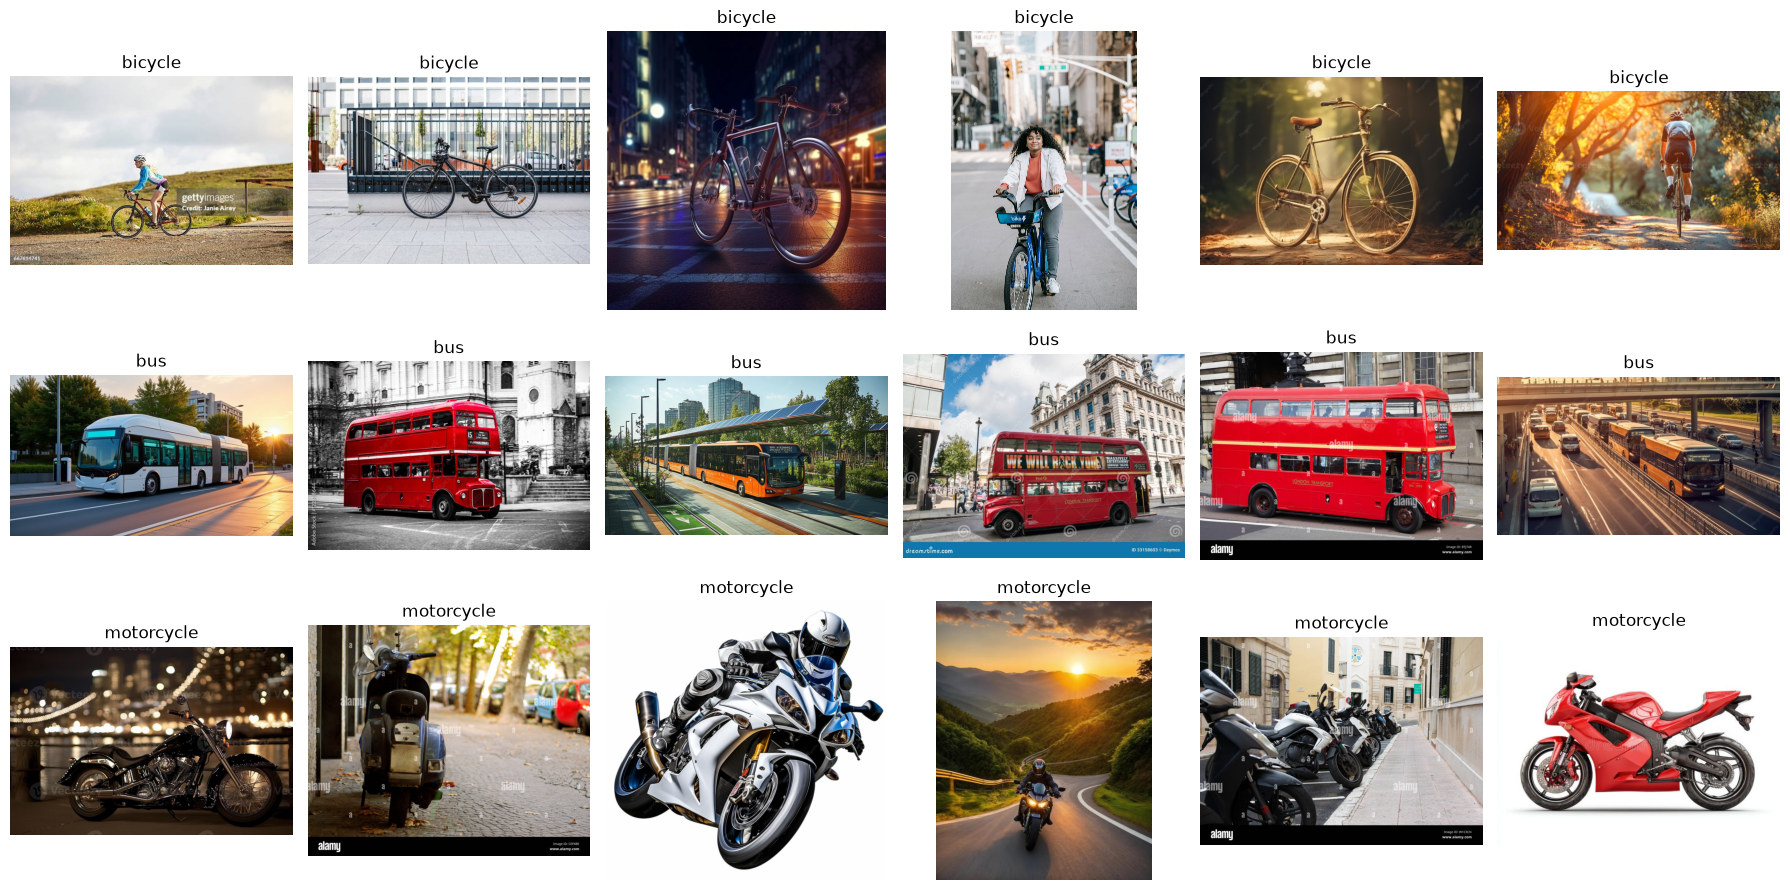

In [9]:
def show_random_images(root, n_per_class=6):
    root = Path(root)
    class_dirs = [p for p in sorted(root.iterdir()) if p.is_dir()]
    fig, axes = plt.subplots(len(class_dirs), n_per_class, figsize=(3*n_per_class, 3*len(class_dirs)))
    if len(class_dirs) == 1:
        axes = np.expand_dims(axes, 0)
    for row, class_dir in enumerate(class_dirs):
        files = list(class_dir.glob("*.jpg"))
        chosen = random.sample(files, min(n_per_class, len(files)))
        for col in range(n_per_class):
            ax = axes[row, col]
            if col < len(chosen):
                img = Image.open(chosen[col])
                ax.imshow(img)
                ax.set_title(class_dir.name)
            ax.axis("off")
    plt.tight_layout()

show_random_images(RAW_DIR)

### Limpieza semántica aplicada

Cada imagen descargada se revisó visualmente con hojas de contacto. Se eliminan las siguientes, con su motivo:

In [10]:
REMOVED = {
    "bicycle": {
        "0056": "noche, la bicicleta casi no se ve",
        "0065": "calle con motos/scooters además de bicicletas (dos clases en la imagen)",
        "0066": "foto vertical de una ciclovía; el objeto es mínimo",
        "0095": "ilustración, no fotografía",
        "0076": "casi duplicado de 0073 (misma sesión de fotos)",
        "0077": "casi duplicado de 0073 (misma sesión de fotos)",
        "0097": "casi duplicado de 0073 (misma sesión de fotos)",
        "0080": "casi duplicado de 0078 (misma sesión de fotos)",
        "0085": "casi duplicado de 0078 (misma sesión de fotos)",
        "0086": "casi duplicado de 0072 (mismo ciclista, fondo blanco)",
    },
    "bus": {
        "0017": "embotellamiento con muchos carros; el bus no es el objeto principal",
        "0029": "calle nocturna; el bus casi no se ve",
        "0036": "misma foto que 0002 (otro banco de imágenes)",
        "0043": "ilustración",
        "0048": "ciclista en primer plano (mezcla con la clase bicycle)",
        "0050": "ilustración",
        "0053": "vista aérea de una intersección",
        "0054": "ilustración",
        "0055": "ilustración",
        "0063": "objetos verdes, no es un bus",
        "0065": "interior de un bus con personas",
        "0066": "calle sin bus visible",
        "0067": "calle sin bus visible",
    },
    "motorcycle": {
        "0026": "persona meditando en primer plano; imagen artística ambigua",
        "0045": "primer plano oscuro, el objeto no se distingue",
        "0046": "texto 'FOR CYCLES' en el piso (texto que puede revelar la etiqueta)",
        "0047": "callejón oscuro; parecen bicicletas",
        "0050": "primer plano de una rueda; el objeto no se distingue",
        "0062": "calle oscura; objeto ambiguo",
        "0076": "fondo de transparencia (mockup)",
        "0093": "collage de 4 motos idénticas",
        "0094": "mockup PSD con fondo de transparencia",
        "0098": "collage de 4 motos idénticas",
        "0099": "ilustración artística (moto y caballo)",
        "0102": "collage de 4 motos idénticas",
        "0103": "render fantasioso, no una moto real",
    },
}

removed_now = 0
for class_name, files in REMOVED.items():
    for stem in files:
        path = RAW_DIR / class_name / f"{stem}.jpg"
        if path.exists():
            path.unlink()
            removed_now += 1

print("Imágenes eliminadas en total:", sum(len(v) for v in REMOVED.values()), "| en esta ejecución:", removed_now)
print("Imágenes por clase después de la limpieza:", count_images(RAW_DIR))

Imágenes eliminadas en total: 36 | en esta ejecución: 0
Imágenes por clase después de la limpieza: {'bicycle': 93, 'bus': 86, 'motorcycle': 91}


### Checkpoint del dataset

Antes de continuar, asegúrate de que:

- cada carpeta contiene imágenes realmente asociadas a su clase;
- no predominan logos, dibujos o texto que revele la etiqueta;
- no hay una diferencia de fondo/estilo demasiado obvia entre clases;
- el número de imágenes por clase es razonablemente balanceado.

Registra aquí el número de imágenes eliminadas y el problema de calidad más frecuente.

**Registro de la limpieza:**

- Descargadas: 306 (bicycle 103, bus 99, motorcycle 104). Ninguna fue inválida para TensorFlow.
- **Eliminadas: 36** (bicycle 10, bus 13, motorcycle 13). Finales: **bicycle 93, bus 86, motorcycle 91**, razonablemente balanceadas, aunque por debajo de la meta de 100–150 por clase.
- **Problemas más frecuentes** (empate, 12 imágenes cada uno): ilustraciones, mockups, collages o renders, y escenas donde el objeto casi no se ve (noche, vista aérea, calle sin el objeto). Les siguen 7 casi duplicados de la misma sesión de fotos (riesgo de *leakage* entre train y test), 2 imágenes con dos clases, 2 escenas ambiguas con personas en primer plano y 1 con texto que revela la etiqueta ("FOR CYCLES").
- **Sesgos que permanecen:** unos 30 de los 86 buses son *double-deckers* rojos de Londres; muchas motos están sobre fondo blanco de estudio; bicicletas y motos incluyen varias imágenes generadas por IA con atardecer. Las marcas de agua de bancos de imágenes aparecen en las tres clases, así que no identifican una sola.

# 4. Separar train, validation y test — EN CLASE

> **Concepto clave — tres conjuntos, tres funciones**
>
> - **Train:** se utiliza para actualizar los pesos del modelo.
> - **Validation:** se utiliza durante el desarrollo para decidir épocas, `learning_rate`, número de capas a descongelar, etc.
> - **Test:** se reserva para medir el rendimiento final. No debe guiar las decisiones de entrenamiento.

Usaremos **70 % entrenamiento, 15 % validación y 15 % prueba**.

In [11]:
SPLIT_DIR = Path("dataset")

def split_dataset(source_root, destination_root, train_ratio=0.70, val_ratio=0.15, seed=SEED):
    source_root = Path(source_root)
    destination_root = Path(destination_root)
    if destination_root.exists():
        shutil.rmtree(destination_root)
    rng = random.Random(seed)

    for class_dir in sorted(source_root.iterdir()):
        if not class_dir.is_dir():
            continue
        files = list(class_dir.glob("*.jpg"))
        rng.shuffle(files)
        n = len(files)
        n_train = int(n * train_ratio)
        n_val = int(n * val_ratio)
        splits = {
            "train": files[:n_train],
            "validation": files[n_train:n_train+n_val],
            "test": files[n_train+n_val:],
        }
        for split_name, split_files in splits.items():
            target = destination_root / split_name / class_dir.name
            target.mkdir(parents=True, exist_ok=True)
            for src in split_files:
                shutil.copy2(src, target / src.name)

split_dataset(RAW_DIR, SPLIT_DIR)
for split in ["train", "validation", "test"]:
    print(split, count_images(SPLIT_DIR / split))

train {'bicycle': 65, 'bus': 60, 'motorcycle': 63}
validation {'bicycle': 13, 'bus': 12, 'motorcycle': 13}
test {'bicycle': 15, 'bus': 14, 'motorcycle': 15}


### Comprobación conceptual

Explica brevemente: ¿por qué usar repetidamente el conjunto de prueba para escoger épocas, `learning_rate` o capas a descongelar termina contaminando nuestra estimación de desempeño?

**Respuesta:** Cada vez que una decisión (epochs, `learning_rate`, capas a descongelar) se toma porque mejora el resultado en test, el test pasa a formar parte del proceso de ajuste: el modelo y sus hiperparámetros se adaptan a esas imágenes concretas, incluido su ruido. La métrica final queda **optimista**, porque ya no mide el desempeño sobre datos que el proceso nunca vio, y el test se convierte en otra validación. Por eso las decisiones se toman con *validation* y el test se usa una sola vez, al final.

# 5. Construir los datasets de Keras — EN CLASE

`image_dataset_from_directory()` construye un `tf.data.Dataset` usando el nombre de las carpetas como clases.

Observa que:

- `train` se mezcla (`shuffle=True`);
- `validation` y `test` mantienen un orden estable;
- todas las imágenes se redimensionan a `224×224` para EfficientNetB0.

In [12]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = keras.utils.image_dataset_from_directory(
    SPLIT_DIR / "train", image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    label_mode="int", shuffle=True, seed=SEED)
val_ds = keras.utils.image_dataset_from_directory(
    SPLIT_DIR / "validation", image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    label_mode="int", shuffle=False)
test_ds = keras.utils.image_dataset_from_directory(
    SPLIT_DIR / "test", image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    label_mode="int", shuffle=False)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)
print(class_names)

Found 188 files belonging to 3 classes.


Found 38 files belonging to 3 classes.


Found 44 files belonging to 3 classes.


['bicycle', 'bus', 'motorcycle']


# 6. Primer modelo: transfer learning — EN CLASE

Usaremos **EfficientNetB0** preentrenada en ImageNet. Primero congelaremos completamente la red base y entrenaremos solo una nueva cabeza de clasificación.

> **Concepto clave — Data augmentation**
>
> `RandomFlip`, `RandomRotation` y `RandomZoom` generan variaciones plausibles durante el entrenamiento. No crean información nueva, pero ayudan a que el modelo dependa menos de detalles accidentales de las imágenes descargadas.

> **Concepto clave — GlobalAveragePooling2D**
>
> En lugar de aplanar todos los mapas de características con `Flatten`, `GlobalAveragePooling2D` resume cada canal en un solo valor. Así reducimos mucho el número de parámetros de la cabeza de clasificación.

In [13]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
], name="augmentation")

base_model = keras.applications.EfficientNetB0(
    include_top=False, weights="imagenet", input_shape=(*IMG_SIZE, 3))
base_model.trainable = False

inputs = keras.Input(shape=(*IMG_SIZE, 3))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)
model = keras.Model(inputs, outputs)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,053,414 (15.46 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

## TODO 3 — EN CLASE: entrena la cabeza de clasificación

La base EfficientNet está congelada. Tu trabajo es configurar y entrenar la nueva cabeza.

> **Concepto clave — EarlyStopping**
>
> `EarlyStopping` detiene el entrenamiento cuando `val_loss` deja de mejorar. Con `restore_best_weights=True`, Keras recupera los pesos de la mejor época observada en validación.

Antes de ejecutar, escribe una predicción corta:

- ¿esperas que `train_accuracy` suba rápidamente?
- ¿qué señal en las curvas indicaría overfitting?

Completa únicamente los espacios `TODO` del código siguiente.

**Predicción (antes de ejecutar):**

- Sí: espero que `train_accuracy` suba **rápido** (por encima del 90 % en pocas epochs). EfficientNetB0 fue entrenada en ImageNet, que incluye clases como *mountain bike*, *school bus*, *trolleybus*, *moped* y *motor scooter*, así que sus features ya separan estos vehículos y solo se entrena la cabeza nueva.
- Señal de overfitting: que `loss` siga bajando mientras `val_loss` empieza a subir, o que `accuracy` siga creciendo mientras `val_accuracy` se estanca o baja, abriendo una brecha entre ambas curvas.

In [14]:
# TODO 3 — EN CLASE: completa la configuración de entrenamiento

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),  # 1e-3
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],                                 # "accuracy"
)

early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",            # "val_loss"
    patience=2,
    restore_best_weights=True,
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stopping],
)

Epoch 1/10


.venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


1/6 ━━━━━━━━━━━━━━━━━━━━ 16s 3s/step - accuracy: 0.2812 - loss: 1.3367

2/6 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step - accuracy: 0.3594 - loss: 1.1966

3/6 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - accuracy: 0.4375 - loss: 1.1450

...

3/6 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step - accuracy: 0.9792 - loss: 0.1214

4/6 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step - accuracy: 0.9844 - loss: 0.1188

5/6 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step - accuracy: 0.9875 - loss: 0.1080

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - accuracy: 0.9840 - loss: 0.1085

6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 299ms/step - accuracy: 0.9840 - loss: 0.1085 - val_accuracy: 0.9737 - val_loss: 0.0792


### Curvas de aprendizaje — EN CLASE si el tiempo lo permite

Grafica `accuracy`, `val_accuracy`, `loss` y `val_loss`.

Si el tiempo de clase termina antes, **puedes completar estas curvas en casa**.  
Lo obligatorio antes de salir es haber entrenado el primer modelo y tener sus métricas de entrenamiento/validación.

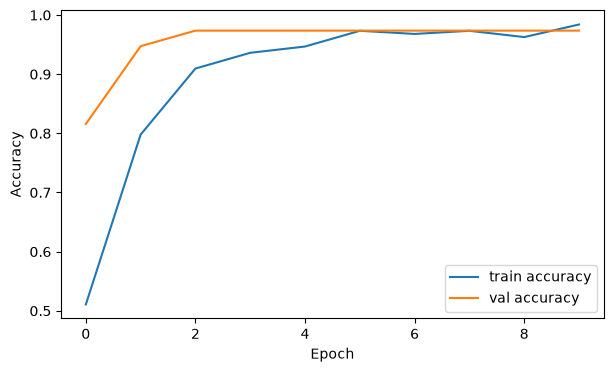

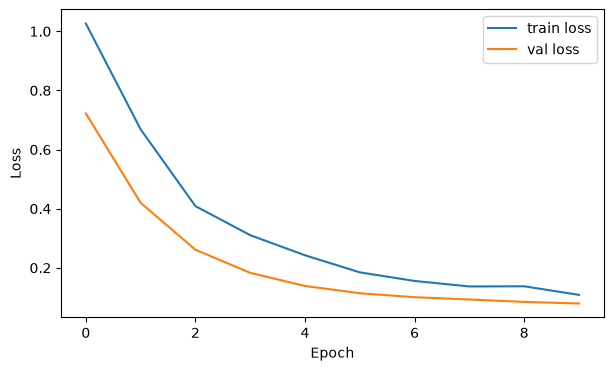

Epochs ejecutadas: 10 | mejor epoch (val_loss): 10
accuracy = 0.9840 | val_accuracy = 0.9737


In [15]:
# Completa las cuatro curvas usando el objeto history
plt.figure(figsize=(7, 4))
plt.plot(history.history["accuracy"], label="train accuracy")
plt.plot(history.history["val_accuracy"], label="val accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

best = int(np.argmin(history.history["val_loss"]))
print(f"Epochs ejecutadas: {len(history.history['loss'])} | mejor epoch (val_loss): {best + 1}")
print(f"accuracy = {history.history['accuracy'][best]:.4f} | val_accuracy = {history.history['val_accuracy'][best]:.4f}")

**Lectura de las curvas (ejecución mostrada):**

- `accuracy` subió de 0.51 (epoch 1) a 0.98 (epoch 10); `val_accuracy` de 0.82 a **0.97** desde la epoch 3 (37 de 38 imágenes de validación).
- `val_loss` bajó en **todas** las epochs (0.72 → 0.079), por lo que `EarlyStopping` no se activó y se usaron las 10 epochs.
- `val_loss` queda por debajo de `loss` porque Dropout y data augmentation solo están activos en entrenamiento.
- **No hay señal de overfitting**: no aparece una brecha creciente ni sube `val_loss`. La predicción se cumplió.

# PUNTO DE CONTROL — FIN DEL TRABAJO EN CLASE

Antes de continuar, verifica que tu equipo tenga:

- [x] 3 clases definidas;
- [x] términos de búsqueda documentados;
- [x] imágenes descargadas;
- [x] dataset inspeccionado y parcialmente limpiado;
- [x] separación `train / validation / test`;
- [x] EfficientNetB0 con pesos de ImageNet;
- [x] backbone congelado;
- [x] nueva cabeza de clasificación;
- [x] al menos un entrenamiento completado;
- [x] `accuracy` y `val_accuracy` reportadas.

## Hasta aquí llega el trabajo de clase.

**No uses todavía el conjunto de test para tomar decisiones.**

---

# PARTE B — TRABAJO EN CASA

A partir de este punto debes completar el análisis de manera autónoma.

Ahora sí vas a:

1. evaluar el modelo en `test`;
2. estudiar la matriz de confusión y métricas por clase;
3. realizar fine-tuning;
4. comparar el modelo congelado contra el modelo ajustado;
5. analizar errores;
6. escribir las conclusiones.

# 7. Evaluación del primer modelo — EN CASA

Ahora sí utilizaremos el conjunto de prueba.

> **Concepto clave — No todo es accuracy**
>
> - **Precision:** de las imágenes que el modelo predijo como una clase, ¿cuántas eran correctas?
> - **Recall:** de las imágenes que realmente pertenecían a una clase, ¿cuántas encontró?
> - **F1:** combina precision y recall.
> - **Matriz de confusión:** muestra qué clases se están confundiendo entre sí.

Guarda esta evaluación: será nuestra línea base antes del fine-tuning.

In [16]:
test_loss_before, test_acc_before = model.evaluate(test_ds, verbose=0)
print(f"Test accuracy antes del fine-tuning: {test_acc_before:.4f}")

Test accuracy antes del fine-tuning: 0.9773


              precision    recall  f1-score   support

     bicycle      1.000     0.933     0.966        15
         bus      1.000     1.000     1.000        14
  motorcycle      0.938     1.000     0.968        15

    accuracy                          0.977        44
   macro avg      0.979     0.978     0.978        44
weighted avg      0.979     0.977     0.977        44



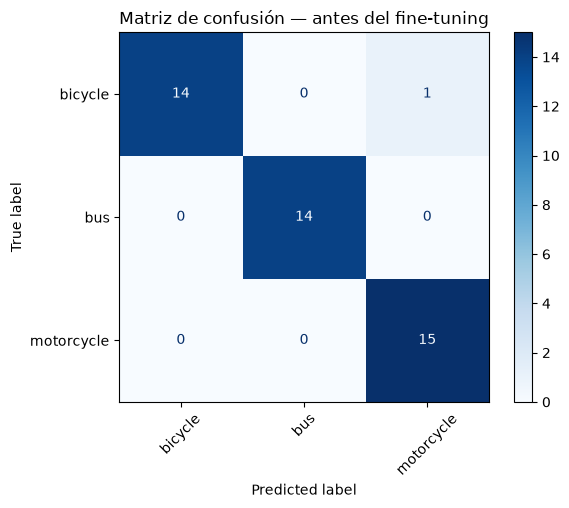

In [17]:
def get_predictions(model, dataset):
    y_true = np.concatenate([y.numpy() for _, y in dataset])
    probabilities = model.predict(dataset, verbose=0)
    y_pred = probabilities.argmax(axis=1)
    return y_true, y_pred, probabilities

y_true, y_pred, probabilities = get_predictions(model, test_ds)
print(classification_report(y_true, y_pred, target_names=class_names, digits=3))
cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names).plot(cmap="Blues", xticks_rotation=45)
plt.title("Matriz de confusión — antes del fine-tuning")
plt.show()

## TODO 4 — EN CASA: interpreta la evaluación

Utilizando `classification_report` y la matriz de confusión, responde:

1. ¿Cuál clase obtuvo mejores resultados?
2. ¿Cuál fue la principal confusión?
3. ¿La accuracy global oculta algún problema por clase?
4. ¿Qué cambiarías primero en el **dataset** antes de cambiar el modelo?

**Respuesta TODO 4** (modelo con backbone congelado, test = 44 imágenes):

1. **Bus**: precision, recall y F1 = 1.000 (14/14).
2. **Bicycle → motorcycle**: es la única confusión, 1 bicicleta clasificada como moto. Por eso el recall de bicycle es 0.933 y la precision de motorcycle 0.938.
3. La accuracy global (0.977) no oculta un problema grande, pero sí dos matices: (a) el único error va en una dirección concreta (bicicleta→moto), que también se repite en validación y train (sección 10); (b) con 44 imágenes cada error mueve la accuracy unos 2.3 puntos, así que la estimación es poco precisa.
4. **En el dataset**: añadir más bicicletas en las situaciones donde falla (filas de bicicletas compartidas o estacionadas en la acera, vista POV desde el manubrio), revisar si la clase moto tiene muchas fotos con esos mismos encuadres y aumentar el número de imágenes por clase, en particular para test.

# 8. Fine-tuning — EN CASA

Ahora permitiremos que una pequeña parte de EfficientNet se adapte al nuevo problema.

> **Concepto clave — Fine-tuning**
>
> En la fase anterior, los pesos del backbone no cambiaron. Ahora descongelaremos únicamente una parte final del modelo y la actualizaremos con un **learning rate mucho menor**.

> **Concepto clave — Batch Normalization**
>
> EfficientNet contiene capas `BatchNormalization`, que mantienen estadísticas internas aprendidas durante el entrenamiento. En datasets pequeños conviene mantenerlas congeladas durante fine-tuning para evitar actualizaciones inestables de esas estadísticas.

Después de cambiar qué capas son entrenables, es necesario **recompilar** el modelo.

In [18]:
base_model.trainable = True

# TODO 5 — Decide cuántas capas finales adaptar.
# Empieza con ~20. Puedes justificar otro valor usando validation.
N_UNFROZEN = 20

for layer in base_model.layers[:-N_UNFROZEN]:
    layer.trainable = False

# Mantener Batch Normalization congelado.
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

print(
    "Capas entrenables de la base:",
    sum(layer.trainable for layer in base_model.layers),
    "/",
    len(base_model.layers),
)

Capas entrenables de la base: 15 / 238


## TODO 5 — EN CASA: realiza fine-tuning

Recompila y continúa el entrenamiento.

Usa como punto de partida:

- `Adam(learning_rate=1e-5)`;
- `SparseCategoricalCrossentropy`;
- `accuracy`;
- entre **3 y 8 épocas** adicionales;
- `EarlyStopping` sobre `val_loss`.

Tu decisión principal aquí es **cuántas capas descongelar**. Justifícala usando el desempeño de validación, no el conjunto de prueba.

In [19]:
# TODO 5 — EN CASA: completa el fine-tuning

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),  # 1e-5
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
)

early_stopping_ft = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True,
)

history_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8,  # entre 3 y 8
    callbacks=[early_stopping_ft],
)

Epoch 1/8


.venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


1/6 ━━━━━━━━━━━━━━━━━━━━ 19s 4s/step - accuracy: 0.9375 - loss: 0.1012

2/6 ━━━━━━━━━━━━━━━━━━━━ 1s 304ms/step - accuracy: 0.9531 - loss: 0.1118

3/6 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step - accuracy: 0.9688 - loss: 0.1183

...

3/6 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step - accuracy: 0.9688 - loss: 0.1019

4/6 ━━━━━━━━━━━━━━━━━━━━ 0s 281ms/step - accuracy: 0.9766 - loss: 0.0966

5/6 ━━━━━━━━━━━━━━━━━━━━ 0s 281ms/step - accuracy: 0.9812 - loss: 0.0879

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step - accuracy: 0.9787 - loss: 0.0857

6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 359ms/step - accuracy: 0.9787 - loss: 0.0857 - val_accuracy: 0.9737 - val_loss: 0.0644


In [20]:
best_ft = int(np.argmin(history_ft.history["val_loss"]))
print(f"Epochs de fine-tuning ejecutadas: {len(history_ft.history['loss'])} | mejor epoch: {best_ft + 1}")
print(f"val_loss antes del fine-tuning : {min(history.history['val_loss']):.4f} | val_accuracy: {history.history['val_accuracy'][int(np.argmin(history.history['val_loss']))]:.4f}")
print(f"val_loss después del fine-tuning: {history_ft.history['val_loss'][best_ft]:.4f} | val_accuracy: {history_ft.history['val_accuracy'][best_ft]:.4f}")

Epochs de fine-tuning ejecutadas: 8 | mejor epoch: 8
val_loss antes del fine-tuning : 0.0792 | val_accuracy: 0.9737
val_loss después del fine-tuning: 0.0644 | val_accuracy: 0.9737


**Decisión TODO 5:** `N_UNFROZEN = 20` (el punto de partida sugerido), lo que deja **15 capas entrenables de 238** porque las BatchNormalization siguen congeladas; `Adam(1e-5)`; hasta 8 epochs con `EarlyStopping(val_loss)`.

- **Justificación con validation:** con 188 imágenes de entrenamiento, descongelar muchas capas aumenta el riesgo de sobreajuste. Con 20 capas, `val_loss` bajó en las 8 epochs (de 0.079 antes del fine-tuning a **0.064**) sin señales de sobreajuste, y `val_accuracy` se mantuvo en 0.9737.
- **Limitación:** no se compararon otros valores de `N_UNFROZEN` (por ejemplo 40 o 60) en validación. `EarlyStopping` no se activó porque `val_loss` siguió bajando hasta la epoch 8, el máximo sugerido.

# 9. Comparación final — EN CASA

Compara el desempeño del mismo sistema **antes y después** del fine-tuning.

Una mejora pequeña también puede ser válida. Si el resultado empeora, no significa que el experimento “salió mal”: debes interpretar por qué pudo ocurrir.

In [21]:
test_loss_after, test_acc_after = model.evaluate(test_ds, verbose=0)
print(f"Antes del fine-tuning  : {test_acc_before:.4f}")
print(f"Después del fine-tuning: {test_acc_after:.4f}")
print(f"Diferencia              : {test_acc_after-test_acc_before:+.4f}")

Antes del fine-tuning  : 0.9773
Después del fine-tuning: 0.9773
Diferencia              : +0.0000


              precision    recall  f1-score   support

     bicycle      1.000     0.933     0.966        15
         bus      1.000     1.000     1.000        14
  motorcycle      0.938     1.000     0.968        15

    accuracy                          0.977        44
   macro avg      0.979     0.978     0.978        44
weighted avg      0.979     0.977     0.977        44



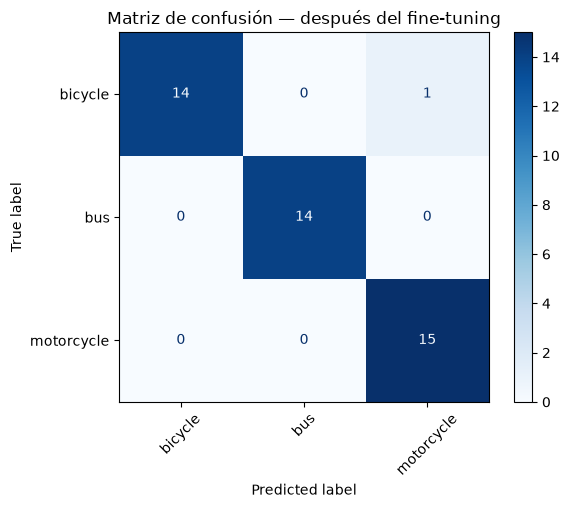

In [22]:
y_true_ft, y_pred_ft, probabilities_ft = get_predictions(model, test_ds)
print(classification_report(y_true_ft, y_pred_ft, target_names=class_names, digits=3))
cm_ft = confusion_matrix(y_true_ft, y_pred_ft)
ConfusionMatrixDisplay(confusion_matrix=cm_ft, display_labels=class_names).plot(cmap="Blues", xticks_rotation=45)
plt.title("Matriz de confusión — después del fine-tuning")
plt.show()

**Comparación antes/después:** la accuracy en test es **0.9773 antes y después** del fine-tuning (diferencia +0.0000), con el mismo `classification_report` y la misma matriz de confusión: el mismo error bicicleta→moto. El fine-tuning solo mejoró la **pérdida de validación** (0.079 → 0.064), es decir, predicciones algo más seguras, pero no cambió ningún acierto. Interpretación: las features de ImageNet ya separan casi perfectamente estas tres clases y quedaba poco margen; además, con 44 imágenes de test una mejora menor a un acierto no se puede observar.

# 10. Analiza los errores — EN CASA

Una métrica no explica por qué falla un modelo. Debes inspeccionar ejemplos clasificados incorrectamente.

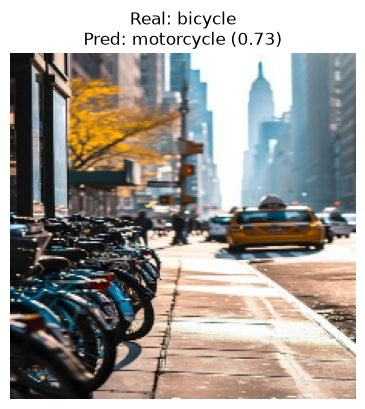

In [23]:
def show_mistakes(dataset, model, class_names, max_images=12):
    mistakes = []
    for images, labels in dataset:
        probs = model.predict(images, verbose=0)
        preds = probs.argmax(axis=1)
        for image, true_label, pred_label, prob in zip(images.numpy(), labels.numpy(), preds, probs):
            if true_label != pred_label:
                mistakes.append((image.astype("uint8"), int(true_label), int(pred_label), float(prob[pred_label])))
    random.shuffle(mistakes)
    mistakes = mistakes[:max_images]
    if not mistakes:
        print("No se encontraron errores en este conjunto.")
        return
    cols = 4
    rows = int(np.ceil(len(mistakes)/cols))
    plt.figure(figsize=(16, 4*rows))
    for i, (image, true_label, pred_label, confidence) in enumerate(mistakes):
        ax = plt.subplot(rows, cols, i+1)
        ax.imshow(image)
        ax.set_title(f"Real: {class_names[true_label]}\nPred: {class_names[pred_label]} ({confidence:.2f})")
        ax.axis("off")
    plt.tight_layout()

show_mistakes(test_ds, model, class_names)

test      : 1 errores de 44


validation: 1 errores de 38


train     : 3 errores de 188
  [error     ] test       bicycle/0040.jpg  real=bicycle    pred=motorcycle confianza=0.73
  [error     ] validation bicycle/0039.jpg  real=bicycle    pred=motorcycle confianza=0.68
  [error     ] train      bicycle/0030.jpg  real=bicycle    pred=motorcycle confianza=0.69
  [error     ] train      bicycle/0041.jpg  real=bicycle    pred=motorcycle confianza=0.73
  [error     ] train      bicycle/0053.jpg  real=bicycle    pred=motorcycle confianza=0.74
  [casi error] test       motorcycle/0053.jpg  real=motorcycle pred=motorcycle confianza=0.68
  [casi error] test       bicycle/0011.jpg  real=bicycle    pred=bicycle    confianza=0.70
  [casi error] test       bicycle/0014.jpg  real=bicycle    pred=bicycle    confianza=0.71
  [casi error] test       bicycle/0090.jpg  real=bicycle    pred=bicycle    confianza=0.83
  [casi error] test       motorcycle/0073.jpg  real=motorcycle pred=motorcycle confianza=0.86


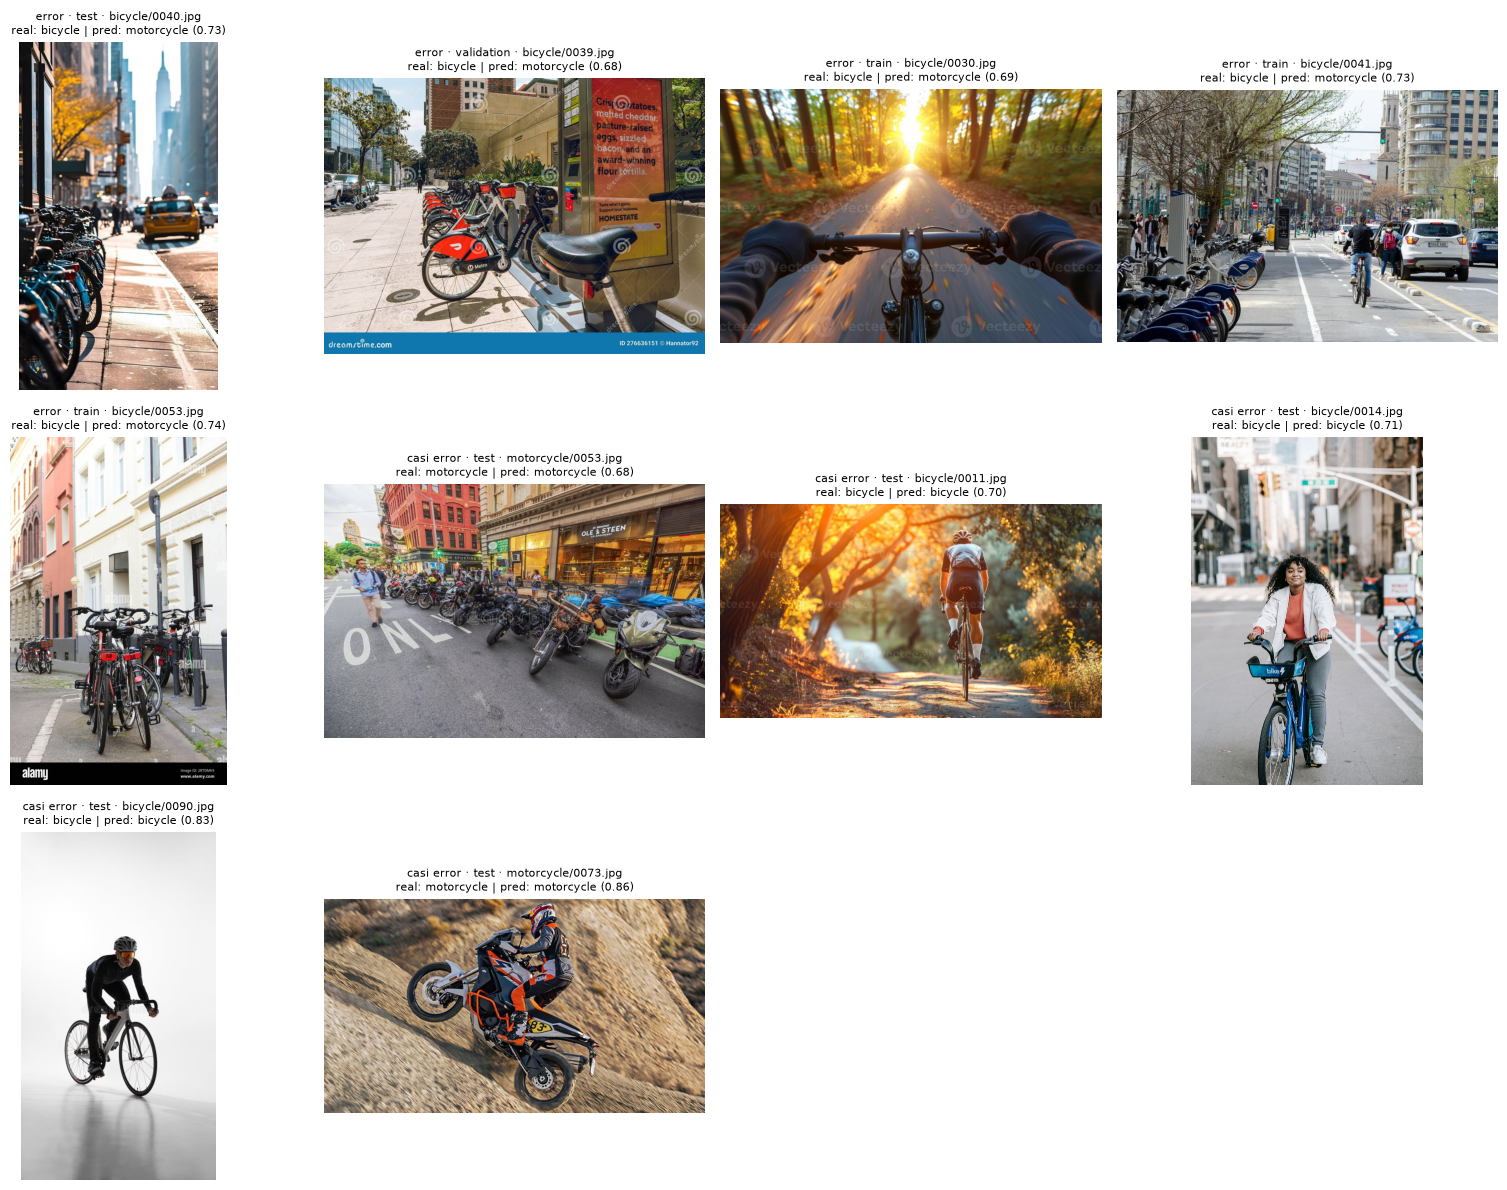

In [24]:
# Errores del modelo final (después del fine-tuning) en test, validation y train, con su archivo.
# Como test solo tiene muy pocos errores, se revisan también los otros conjuntos y las
# predicciones correctas de test con menor confianza ("casi errores").
def predictions_with_files(split):
    ds = keras.utils.image_dataset_from_directory(
        SPLIT_DIR / split, image_size=IMG_SIZE, batch_size=BATCH_SIZE,
        label_mode="int", shuffle=False, verbose=False)
    files = [Path(p) for p in ds.file_paths]
    probs = model.predict(ds, verbose=0)
    y = np.concatenate([lbl.numpy() for _, lbl in ds])
    return files, y, probs

cases = []
for split in ["test", "validation", "train"]:
    files, y, probs = predictions_with_files(split)
    pred = probs.argmax(axis=1)
    wrong = np.flatnonzero(pred != y)
    print(f"{split:10s}: {len(wrong)} errores de {len(y)}")
    cases += [(split, files[k], class_names[y[k]], class_names[pred[k]], float(probs[k, pred[k]]), "error") for k in wrong]
    if split == "test":
        conf_true = probs[np.arange(len(y)), y]
        low = [k for k in np.argsort(conf_true) if pred[k] == y[k]][:5]
        near = [(split, files[k], class_names[y[k]], class_names[pred[k]], float(conf_true[k]), "casi error") for k in low]

cases += near
for split, f, t, p, conf, kind in cases:
    print(f"  [{kind:10s}] {split:10s} {f.parent.name}/{f.name:9s} real={t:10s} pred={p:10s} confianza={conf:.2f}")

cols = 4; rows = int(np.ceil(len(cases) / cols))
plt.figure(figsize=(4 * cols, 4 * rows))
for j, (split, f, t, p, conf, kind) in enumerate(cases):
    plt.subplot(rows, cols, j + 1)
    plt.imshow(Image.open(f))
    plt.title(f"{kind} · {split} · {f.parent.name}/{f.name}\nreal: {t} | pred: {p} ({conf:.2f})", fontsize=8)
    plt.axis("off")
plt.tight_layout()
plt.show()

## TODO 6 — EN CASA: análisis de errores y conclusiones

Test solo tiene **1 error**. Para tener al menos 5, se analizan **todos los errores del modelo final** (después del fine-tuning) en test, validation y train; la celda anterior lista y muestra cada imagen. Como referencia adicional se listan también las 5 predicciones correctas de test con menor confianza ("casi errores").

| Imagen/error | Clase real | Predicción | Causa probable | ¿Cómo lo mejorarías? |
|---|---|---|---|---|
| 1 · test `bicycle/0040` (conf. 0.73) | bicycle | motorcycle | Fila de bicicletas compartidas al borde de una acera, objeto pequeño en una escena urbana; se parece a las filas de motos estacionadas que trajo la búsqueda *motorbike parked on street*. | Agregar bicicletas estacionadas en fila y estaciones de bicicletas compartidas. |
| 2 · validation `bicycle/0039` (0.68) | bicycle | motorcycle | Estación de bicicletas compartidas vista de lado, recortada, con un kiosco y texto publicitario; mismo contexto de "vehículos de dos ruedas en fila en la acera". | Igual que 1; más ejemplos de estaciones de bike-sharing. |
| 3 · train `bicycle/0030` (0.69) | bicycle | motorcycle | Vista POV desde el manubrio en una carretera al atardecer. La clase moto tiene varias imágenes con ese mismo encuadre (POV, carretera, atardecer), así que **el fondo y el encuadre están correlacionados con la clase**. | Equilibrar encuadres: más bicicletas en POV o menos motos POV; revisar las imágenes generadas por IA. |
| 4 · train `bicycle/0041` (0.73) | bicycle | motorcycle | Calle con estación de bicicletas compartidas, carros y un ciclista lejano: el objeto es pequeño y la escena es de tráfico. | Más escenas urbanas de bicicletas; considerar recortes centrados en el objeto. |
| 5 · train `bicycle/0053` (0.74) | bicycle | motorcycle | Bicicletas estacionadas en un rack sobre la acera, vistas de frente y de lejos. | Igual que 1. |

*Casi errores (correctos, con menor confianza en test):* `motorcycle/0053` (0.68, fila de motos junto a la marca "ONLY" de un carril), `bicycle/0011` (0.70, ciclista lejano en un bosque), `bicycle/0014` (0.71, bicicleta compartida con persona en primer plano), `bicycle/0090` (0.83, ciclista en fondo de estudio) y `motorcycle/0073` (0.86, moto de enduro saltando; tipo poco frecuente en el dataset). Confirman el patrón: dudas en escenas de **vehículos de dos ruedas estacionados en la calle** y en estilos poco representados.

**Conclusión:**

1. **Construir el dataset:** los datos de un buscador son ruidosos. Hubo que retirar 36 de 306 imágenes (11.8 %) y aun así quedan sesgos de estilo (buses rojos de Londres, motos en fondo de estudio, imágenes generadas por IA).
2. **Principal problema de calidad:** ilustraciones, mockups y collages, y escenas donde el objeto no se ve (12 imágenes cada uno), además de casi duplicados que habrían filtrado información entre train y test.
3. **Cambio con fine-tuning:** accuracy en test 0.9773 → 0.9773 (+0.00 puntos); `val_loss` 0.079 → 0.064.
4. **¿Ayudó?** No en aciertos de test; solo hizo las predicciones de validación algo más seguras. Las features de ImageNet ya bastaban para estas clases, el ajuste fue pequeño (15 capas, `lr=1e-5`, 8 epochs) y un test de 44 imágenes no permite ver mejoras menores a un acierto.
5. **Qué mejoraría primero:** los **datos**. Todos los errores son sistemáticos (bicicleta→moto en las mismas situaciones), así que la mejora más directa es reunir bicicletas en esos contextos, reducir las correlaciones de estilo y ampliar el test. Entrenamiento y arquitectura vienen después.

# Extensión opcional — Prueba con una imagen externa

Busca una imagen que **no esté en tu dataset** y prueba el modelo. Esta parte no cuenta como un TODO principal, pero sirve como comprobación cualitativa de generalización.

In [25]:
# OPCIONAL
# EXTERNAL_IMAGE_URL = "https://..."
# response = requests.get(EXTERNAL_IMAGE_URL, timeout=10)
# response.raise_for_status()
# img = Image.open(io.BytesIO(response.content)).convert("RGB")
# img_resized = img.resize(IMG_SIZE)
# x = np.array(img_resized, dtype="float32")[None, ...]
# p = model.predict(x, verbose=0)[0]
# plt.imshow(img)
# plt.axis("off")
# plt.title(f"{class_names[p.argmax()]} — confianza {p.max():.2f}")
# plt.show()

*Extensión opcional: no se realizó.*

# 🏠 Cierre conceptual — ENTREGA

Como parte del **TODO 6**, explica con tus propias palabras la diferencia entre:

- **feature extraction / transfer learning con base congelada**;
- **fine-tuning**;
- **entrenar una CNN desde cero**.

No describas solo el código. Explica **qué parámetros se están aprendiendo y de dónde viene el conocimiento inicial**.

**Respuesta (cierre conceptual):**

- **Feature extraction / base congelada:** solo se aprenden los pesos de la **cabeza nueva**: `Dense(3)` sobre los 1280 valores de `GlobalAveragePooling2D`, es decir, $1280\times3+3=3843$ parámetros. Los millones de pesos convolucionales de EfficientNetB0 no cambian; todo el conocimiento visual (bordes, texturas, partes de objetos) viene del **preentrenamiento en ImageNet**, y nuestro dataset solo enseña a combinar esas features para separar las tres clases.
- **Fine-tuning:** además de la cabeza se actualizan los pesos de las **últimas capas** del backbone (aquí 15, con las BatchNormalization congeladas), con un `learning_rate` muy pequeño (`1e-5`). El punto de partida sigue siendo ImageNet; solo se ajustan ligeramente las features más abstractas a nuestras clases, sin destruir lo ya aprendido.
- **Entrenar una CNN desde cero:** **todos** los parámetros (unos 4 millones en EfficientNetB0) parten de valores aleatorios y todo el conocimiento debe salir de nuestras ~190 imágenes de entrenamiento. Con tan pocos datos el modelo memorizaría el train y generalizaría mal; por eso el transfer learning es la opción adecuada aquí.

# Reto opcional

Elige **uno**:

**A. Más datos:** duplica el número de imágenes manteniendo el modelo igual.  
**B. Otro backbone:** prueba MobileNetV3, ResNet50 o EfficientNetV2B0.  
**C. Dataset difícil:** agrega una cuarta clase visualmente parecida.  
**D. Ablation:** entrena sin `data_augmentation` y compara.

Cambia **una sola variable a la vez**.

*Reto opcional: no se realizó.*

# ✅ Checklist de entrega

Antes de entregar verifica:

### Evidencia del trabajo en clase
- [x] Problema y clases definidos.
- [x] Dataset construido y revisado.
- [x] Train / validation / test creados.
- [x] Primer modelo con backbone congelado entrenado.

### Trabajo en casa
- [x] Evaluación sobre test.
- [x] Matriz de confusión.
- [x] Precision / recall / F1 interpretados.
- [x] Fine-tuning ejecutado.
- [x] Comparación antes vs. después del fine-tuning.
- [x] Al menos 5 errores analizados.
- [x] Conclusión final escrita.

### Opcional
- [ ] Imagen externa.
- [ ] Experimento adicional / reto.

# Rúbrica sugerida

| Componente | Peso |
|---|---:|
| TODO 1 — Problema y estrategia de búsqueda | 10% |
| TODO 2 — Construcción, inspección y limpieza del dataset | 20% |
| Split y pipeline de datos | 10% |
| TODO 3 — Transfer learning + curvas | 20% |
| TODO 4 — Evaluación e interpretación | 10% |
| TODO 5 — Fine-tuning y comparación | 15% |
| TODO 6 — Análisis de errores + conclusión conceptual | 15% |
| **Total** | **100%** |